# 데이터 불러오기 

In [1]:
import pandas as pd
import numpy as np

In [2]:
# 모든 열을 출력하도록 설정
pd.set_option('display.max_columns', None)

In [311]:
# 수도권 자료 불러오기
# 오픈런 공연만 포함 / 비오픈런 공연도 아래와 같이 전처리 과정 진행
df = pd.read_csv('공연_23_수도권_경상_Y.csv')

# 변수 전처리 

In [312]:
# datatime 형식으로 변경 
df['공연시작일자'] = pd.to_datetime(df['공연시작일자'])
df['공연종료일자'] = pd.to_datetime(df['공연종료일자'])
df['공연일시'] = pd.to_datetime(df['공연일시'])

In [325]:
#'공연기간' 열에서 'days' 이후의 시간을 제거하고 'days'로 통일
df['공연기간'] = df['공연기간'].astype(str)  # 먼저 문자열로 변환 (필요한 경우)
df['공연기간'] = df['공연기간'].str.extract(r'(\d+ days)')[0]

# 결과 확인
df['공연기간'].value_counts()

공연기간
273 days    36689
274 days    30842
364 days    28646
303 days    11240
360 days    11092
296 days     9169
289 days     8959
Name: count, dtype: int64

In [322]:
# 소요시간을 '분'으로 통일하고 '분'을 제거해준다. 

import re

def convert_to_minutes(time_str):
    # 숫자와 단위를 분리하기 위해 정규 표현식 사용
    time_str = time_str.lower()  # 소문자로 변환 (예: '시간', '분'의 일관성 확보)
    
    hours = 0
    minutes = 0
    
    # "시간"과 "분"이라는 단어가 있는지 확인하고 값을 추출
    if '시간' in time_str:
        hours = int(re.search(r'(\d+)\s*시간', time_str).group(1))
    if '분' in time_str:
        minutes = int(re.search(r'(\d+)\s*분', time_str).group(1))
        
    # 총 분으로 환산
    total_minutes = hours * 60 + minutes
    return total_minutes

df['소요시간'] = df['소요시간'].apply(convert_to_minutes)

In [323]:
# 공연일시를 '분기'로 정의 

def get_quarter(date):
    if date.month in [1, 2, 3]:
        return '1분기'
    elif date.month in [4, 5, 6]:
        return '2분기'
    elif date.month in [7, 8, 9]:
        return '3분기'
    else:
        return '4분기'

df['분기'] = df['공연일시'].apply(get_quarter)

In [326]:
# 공연기간을 int값으로 정의

def convert_to_int(period_str):
    return int(period_str.replace('days', '').strip())

# '공연기간' 열을 정수형(int) 값으로 변환하여 저장
df['공연기간'] = df['공연기간'].apply(convert_to_int)

# 학습을 위한 데이터셋 생성

In [331]:
# 공연코드별로 그룹화하고 각 열에 대해 집계
Demo = df.groupby('공연코드').agg({
    '시설특성' : lambda x : ', '.join(x.unique().astype(str)),                    #1
    '편의시설_레스토랑 여부' : lambda x : ', '.join(x.unique().astype(str)),      #2
    '편의시설_카페 여부' : lambda x : ', '.join(x.unique().astype(str)),          #3
    '편의시설_편의점 여부' : lambda x : ', '.join(x.unique().astype(str)),        #4
    '편의시설_놀이방 여부' : lambda x : ', '.join(x.unique().astype(str)),        #5
    '편의시설_수유실 여부' : lambda x : ', '.join(x.unique().astype(str)),        #6
    '장애인시설_주차장 여부' : lambda x : ', '.join(x.unique().astype(str)),      #7
    '장애인시설_화장실 여부' : lambda x : ', '.join(x.unique().astype(str)),      #8
    '장애인시설_경사로 여부' : lambda x : ', '.join(x.unique().astype(str)),      #9
    '장애인시설_전용엘리베이터 여부' : lambda x : ', '.join(x.unique().astype(str)), #10
    '주차시설_자체 여부' : lambda x : ', '.join(x.unique().astype(str)),          #11
    '주차시설_공영 여부' : lambda x : ', '.join(x.unique().astype(str)),          #12
    '좌석수' : lambda x : ', '.join(x.unique().astype(str)),                      #13
    '장애인석' : lambda x : ', '.join(x.unique().astype(str)),                    #14
    '소요시간' : lambda x : ', '.join(x.unique().astype(str)),                    #16
    '장르명' : lambda x : ', '.join(x.unique().astype(str)),                      #17
    '공연지역명' : lambda x : ', '.join(x.unique().astype(str)),                  #18
    '관람연령' : lambda x : ', '.join(x.unique().astype(str)),                    #19
    '아동공연 여부' : lambda x : ', '.join(x.unique().astype(str)),               #20
    '축제 여부' : lambda x : ', '.join(x.unique().astype(str)),                  #21
    '내한공연 여부' : lambda x : ', '.join(x.unique().astype(str)),               #22
    '오픈런 여부' : lambda x : ', '.join(x.unique().astype(str)),                 #23
    '수상실적_개수' : lambda x : ', '.join(x.unique().astype(str)),               #24
    '공연기간' : lambda x : ', '.join(x.unique().astype(str)),                    #25
})

# reset_index()를 통해 index를 재설정 
Demo_df = Demo.reset_index()

# 결과 확인
Demo_df.head()

,공연코드,시설특성,편의시설_레스토랑 여부,편의시설_카페 여부,편의시설_편의점 여부,편의시설_놀이방 여부,편의시설_수유실 여부,장애인시설_주차장 여부,장애인시설_화장실 여부,장애인시설_경사로 여부,장애인시설_전용엘리베이터 여부,주차시설_자체 여부,주차시설_공영 여부,좌석수,장애인석,소요시간,장르명,공연지역명,관람연령,아동공연 여부,축제 여부,내한공연 여부,오픈런 여부,수상실적_개수,공연기간
0,PF317858,민간(대학로 외),N,Y,N,N,N,N,N,N,N,N,Y,176,N,90,뮤지컬,서울,전체 관람가,N,N,N,Y,0,364
1,PF422856,민간(대학로),N,N,N,N,N,N,N,N,N,N,Y,270,N,100,뮤지컬,서울,만 13세 이상,N,N,N,Y,0,364
2,PF423813,민간(대학로),Y,Y,N,N,N,N,N,N,N,N,Y,202,N,100,뮤지컬,서울,만 7세 이상,N,N,N,Y,0,364
3,PF435409,민간(대학로),N,N,N,N,N,N,N,N,N,N,Y,299,N,80,연극,서울,만 13세 이상,N,N,N,Y,0,296
4,PF435506,민간(대학로),N,N,N,N,N,N,N,N,N,N,Y,155,N,90,연극,서울,만 18세 이상,N,N,N,Y,0,303


In [332]:
# 공연 회차 column 생성
df_1 = df.groupby('공연코드').agg({'공연회차' : lambda x : x.sum()}).reset_index()

# merge로 데이터 기존 학습 데이터에 병합
Demo_df = pd.merge(Demo_df,df_1,on = '공연코드')

In [334]:
# '공연코드'와 '분기'별로 그룹화하여 공연 횟수 집계
result = df.groupby(['공연코드', '분기']).size().unstack(fill_value=0)

# 열 이름 변경 (1분기_공연횟수, 2분기_공연횟수, ...)
result.columns = [f'{quarter}_공연횟수' for quarter in result.columns]

# reset_index로 데이터 프레임 정리
df_2 = result.reset_index()

# merge로 데이터 기존 학습 데이터에 병합
Demo_df = pd.merge(Demo_df,df_2,on = '공연코드')

In [341]:
# 공연 장당금액의 min, max, mean column 생성
df_3 = df.groupby('공연코드')['장당금액'].agg(['max', 'min', 'mean']).reset_index()

# merge를 통하여 병합
Demo_df = pd.merge(Demo_df,df_3,on = '공연코드')

Index(['공연코드', 'max', 'min', 'mean'], dtype='object')

In [343]:
# 공연을 관람한 성별 column 생성
df_4 = df.groupby(['공연코드', '성별']).size().unstack(fill_value=0).reset_index()

# merge를 통하여 병합
Demo_df = pd.merge(Demo_df,df_4,on = '공연코드')

# 성별 column에 대해 rename
Demo_df.rename(columns = {1:'남성',2:'여성'},inplace = True)


,공연코드,시설특성,편의시설_레스토랑 여부,편의시설_카페 여부,편의시설_편의점 여부,편의시설_놀이방 여부,편의시설_수유실 여부,장애인시설_주차장 여부,장애인시설_화장실 여부,장애인시설_경사로 여부,장애인시설_전용엘리베이터 여부,주차시설_자체 여부,주차시설_공영 여부,좌석수,장애인석,소요시간,장르명,공연지역명,관람연령,아동공연 여부,축제 여부,내한공연 여부,오픈런 여부,수상실적_개수,공연기간,공연회차,1분기_공연횟수,2분기_공연횟수,3분기_공연횟수,4분기_공연횟수,모바일,웹,전화,기타,다중결제,무통장,상품권,카드,현금,max,min,mean,1,2
0,PF317858,민간(대학로 외),N,Y,N,N,N,N,N,N,N,N,Y,176,N,90,뮤지컬,서울,전체 관람가,N,N,N,Y,0,364,652,137,251,119,145,532,120,0,467,0,25,0,160,0,60000,17500,24019.171779,236,416
1,PF422856,민간(대학로),N,N,N,N,N,N,N,N,N,N,Y,270,N,100,뮤지컬,서울,만 13세 이상,N,N,N,Y,0,364,2753,1167,969,507,110,483,2270,0,383,11,16,0,2343,0,110000,100,11147.766073,2093,660
2,PF423813,민간(대학로),Y,Y,N,N,N,N,N,N,N,N,Y,202,N,100,뮤지컬,서울,만 7세 이상,N,N,N,Y,0,364,25241,5962,5686,6031,7562,20751,4487,3,17302,21,1019,0,6897,2,50000,100,21641.892160,9855,15386
3,PF435409,민간(대학로),N,N,N,N,N,N,N,N,N,N,Y,299,N,80,연극,서울,만 13세 이상,N,N,N,Y,0,296,9169,781,2185,3288,2915,6470,2696,3,4818,201,254,0,3875,21,40000,10000,17920.951031,3516,5653
4,PF435506,민간(대학로),N,N,N,N,N,N,N,N,N,N,Y,155,N,90,연극,서울,만 18세 이상,N,N,N,Y,0,303,11240,1070,2646,2852,4672,8859,2378,3,7734,156,319,2,3009,20,40000,9900,20563.238434,4938,6302


In [105]:
# 축제 여부에 대한 column 생성
df_5 = df.groupby('공연코드').agg({
        '축제 여부' : lambda x : ', '.join(x.unique().astype(str))}).reset_index()

# merge를 통하여 병합
Demo_df = pd.merge(Demo_df,df_5,on = '공연코드')

,공연코드,시설특성,편의시설_레스토랑 여부,편의시설_카페 여부,편의시설_편의점 여부,편의시설_놀이방 여부,편의시설_수유실 여부,장애인시설_주차장 여부,장애인시설_화장실 여부,장애인시설_경사로 여부,장애인시설_전용엘리베이터 여부,주차시설_자체 여부,주차시설_공영 여부,좌석수,장애인석,소요시간,장르명,공연지역명,관람연령,아동공연 여부,내한공연 여부,오픈런 여부,수상실적_개수,공연기간,공연회차,1분기_공연횟수,2분기_공연횟수,3분기_공연횟수,4분기_공연횟수,예매방식_기타,모바일,웹,전화,현장,결제방식_기타,다중결제,무통장,상품권,카드,현금,max,min,mean,남성,여성,축제 여부
0,PF421000,민간(대학로 외),N,N,N,N,N,N,N,N,N,Y,N,200,N,50,뮤지컬,경기도,전체 관람가,Y,N,N,0,32,322,322,0,0,0,0,309,13,0,0,240,0,0,0,82,0,12000,12000,12000.000000,72,250,N
1,PF421016,민간(대학로 외),N,Y,N,N,N,Y,Y,N,Y,Y,N,1727,18,150,뮤지컬,경상도,만 7세 이상,N,N,N,0,85,116170,11483,104687,0,0,0,65858,50288,24,0,30055,7073,9671,0,66108,3263,272500,35000,145029.805458,23875,92295,N
2,PF421083,민간(대학로),N,N,N,N,N,N,N,N,N,N,Y,477,N,150,뮤지컬,서울,만 15세 이상,N,N,N,0,79,33186,16966,16220,0,0,0,26881,6285,20,0,9921,322,7930,0,14975,38,88000,26400,56159.247876,921,32265,N
3,PF421085,민간(대학로),N,N,N,N,N,N,N,N,N,N,Y,401,N,100,뮤지컬,서울,만 13세 이상,N,N,N,0,82,16579,10384,6195,0,0,0,12523,4047,9,0,3550,1698,6364,0,4967,0,77000,15400,44347.638579,746,15833,N
4,PF421176,민간(대학로 외),N,Y,N,N,N,N,N,N,N,N,Y,176,N,100,뮤지컬,서울,만 7세 이상,N,N,N,0,36,70,70,0,0,0,0,62,8,0,0,44,0,3,0,23,0,40000,15000,20742.857143,32,38,N


In [346]:
# 공연_23_수명_특징
# 공연_23_수명_특징의 경우에는 '구간별 mean, std, slope를 구하는 함수'에 작성
df_6 = pd.read_csv('공연_23_수명_특징_Y.csv')
df_6.head()

,공연코드,구간 1 mean,구간 2 mean,구간 3 mean,구간 4 mean,구간 5 mean,구간 1 std,구간 2 std,구간 3 std,구간 4 std,구간 5 std,구간 1 slope,구간 2 slope,구간 3 slope,구간 4 slope,구간 5 slope,Cluster
0,PF423813,20.929461,18.025751,20.971074,19.529167,27.380090,14.524376,14.941531,15.197837,14.321736,18.980621,-1.306052e-06,6.910382e-07,6.060286e-07,1.507310e-06,1.507371e-06,1
1,PF422856,19.760000,17.456522,17.358974,4.829268,2.862069,7.104353,3.131961,5.028797,4.872897,1.922129,-3.758726e-07,4.343427e-07,-1.067606e-06,-1.591866e-06,4.926154e-07,1
2,PF442888,3.000000,5.000000,29.736264,34.521368,41.770000,2.000000,5.700877,17.362690,21.171955,26.481499,6.186726e-07,1.469273e-06,6.863697e-06,3.257136e-06,1.016060e-06,1
3,PF317858,4.444444,5.034483,6.137931,3.680000,4.520000,3.511885,5.778549,5.559574,2.764658,4.619885,-5.323663e-08,9.603675e-07,-6.881939e-07,1.298292e-07,1.248668e-06,1
4,PF435506,20.020408,17.800000,18.406250,21.742574,33.200000,12.244064,11.280855,9.749038,11.128929,24.504792,-7.692796e-07,1.590206e-06,-1.493970e-06,1.419956e-07,3.940142e-06,1


In [347]:
# 만들어진 학습데이터와 cluster 결과를 merge하여 최종적인 dataset을 구성
Demo_df = pd.merge(Demo_df,df_6.loc[:,('공연코드','Cluster')],on = '공연코드')

# 구간별 mean, std, slope를 구하는 함수 (cluster를 위한 데이터 셋)
- 구간별 mean, std, slope를 변수를 통해 clustering을 진행하는 이유
- 분포에 대한 특징을 파악할 수 있기 때문에 구간별 mean, std, slope변수를 구하여 clustering 진행 

In [97]:
# clustering을 위한 Dataset 구성

# 초기 lst 생성 
lst = []

for performance_code in df['공연코드'].unique():
    performance_df = df[df['공연코드'] == performance_code]

    # 공연 시작일과 공연 종료일을 지정
    start_date = performance_df['공연시작일자'].min()
    end_date = performance_df['공연종료일자'].max()

    # 3개의 구간으로 분리 (구간을 3개로 분리하기 위해서는 periods = 4로 설정)
    intervals = pd.date_range(start=start_date, end=end_date, periods=6)

    # 결과를 담는 리스트
    results = []

    # 구간 분리
    for i in range(5):
        interval_start = intervals[i]
        interval_end = intervals[i + 1]
        
        # 구간에 속하는 공연일시를 filter
        section_df = performance_df[(performance_df['공연일시'] >= interval_start) & (performance_df['공연일시'] < interval_end)]
        
        # 이 구간에 속하는 공연 날짜와 시간에 해당하는 '개수'를 계산
        for performance_time, group in section_df.groupby('공연일시'):
            count = len(group)  # Count the number of performances
            
            results.append({
                '공연코드': performance_code,
                '구간': f'구간 {i + 1}',
                '공연일시': performance_time,
                '개수': count
            })

    # 결과를 데이터프레임의 형식으로 출력
    results_df = pd.DataFrame(results)

    try:
        # mean값에 대한 pivot table (구간별 평균 개수)
        mean_pivot = results_df.pivot_table(index=['공연코드'],
                                            columns=['구간'],
                                            values=['개수'],
                                            aggfunc=np.mean)

        # 상단에 있는 '개수' 컬럼 제거 
        mean_pivot.columns = mean_pivot.columns.droplevel(0)

        # 컬럼명 재설정 
        mean_pivot.columns = [f'{col} mean' for col in mean_pivot.columns]

        # reset_index를 통해 정리 
        mean_pivot.reset_index(inplace=True)

        # std에 대한 pivot_table (구간별 개수의 표준편차)
        std_pivot = results_df.pivot_table(index=['공연코드'],
                                           columns=['구간'],
                                           values=['개수'],
                                           aggfunc=np.std)

        # 상단에 있는 '개수' 컬럼 제거 
        std_pivot.columns = std_pivot.columns.droplevel(0)

        # 컬럼명 재설정 
        std_pivot.columns = [f'{col} std' for col in std_pivot.columns]

        # reset_index를 통해 정리 
        std_pivot.reset_index(inplace=True)

        # 공연일시 순서로 results_df 정리 
        results_df = results_df.sort_values(by=['공연일시'])

        # 기울기를 계산하는 함수 
        def calculate_slope(x, y):
            return np.polyfit(x, y, 1)[0]

        # 각 그룹별로 구간에 따른 기울기를 설정 
        results_df['timestamp'] = results_df['공연일시'].values.astype(np.int64) // 10**9  # Convert datetime to a numeric timestamp
        slope_df = results_df.groupby(['공연코드', '구간']).apply(
            lambda group: calculate_slope(group['timestamp'], group['개수'])
        ).reset_index(name='slope')

        # 기울기를 pivot_table로 재설정 
        slope_pivot = slope_df.pivot(index='공연코드', columns='구간', values='slope')

        # 컬럼명 재설정
        slope_pivot.columns = [f'{col} slope' for col in slope_pivot.columns]

        # reset_index를 통해 정리 
        slope_pivot.reset_index(inplace=True)

        # 하나의 행으로 구성 
        merged_df = pd.merge(mean_pivot, std_pivot, on='공연코드')
        merged_df = pd.merge(merged_df, slope_pivot, on='공연코드')

        # lst에 merged_df를 담는다. 
        lst.append(merged_df)

    except KeyError as e:
        print(f"Skipping performance_code {performance_code} due to missing data: {e}")

# 전체 데이터 프레임을 구성 
Demo = pd.concat(lst, ignore_index=True)

# 최종결과 확인
Demo.head()

C:\Users\user\AppData\Local\Temp\ipykernel_9980\2323540086.py:41: FutureWarning: The provided callable <function mean at 0x000002BB487F9EE0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  mean_pivot = results_df.pivot_table(index=['공연코드'],
C:\Users\user\AppData\Local\Temp\ipykernel_9980\2323540086.py:56: FutureWarning: The provided callable <function std at 0x000002BB487FA020> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  std_pivot = results_df.pivot_table(index=['공연코드'],
C:\Users\user\AppData\Local\Temp\ipykernel_9980\2323540086.py:79: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. 

,공연코드,구간 1 mean,구간 2 mean,구간 3 mean,구간 4 mean,구간 5 mean,구간 1 std,구간 2 std,구간 3 std,구간 4 std,구간 5 std,구간 1 slope,구간 2 slope,구간 3 slope,구간 4 slope,구간 5 slope
0,PF423813,20.929461,18.025751,20.971074,19.529167,27.380090,14.524376,14.941531,15.197837,14.321736,18.980621,-1.306052e-06,6.910382e-07,6.060286e-07,1.507310e-06,1.507371e-06
1,PF422856,19.760000,17.456522,17.358974,4.829268,2.862069,7.104353,3.131961,5.028797,4.872897,1.922129,-3.758726e-07,4.343427e-07,-1.067606e-06,-1.591866e-06,4.926154e-07
2,PF442888,3.000000,5.000000,29.736264,34.521368,41.770000,2.000000,5.700877,17.362690,21.171955,26.481499,6.186726e-07,1.469273e-06,6.863697e-06,3.257136e-06,1.016060e-06
3,PF317858,4.444444,5.034483,6.137931,3.680000,4.520000,3.511885,5.778549,5.559574,2.764658,4.619885,-5.323663e-08,9.603675e-07,-6.881939e-07,1.298292e-07,1.248668e-06
4,PF435506,20.020408,17.800000,18.406250,21.742574,33.200000,12.244064,11.280855,9.749038,11.128929,24.504792,-7.692796e-07,1.590206e-06,-1.493970e-06,1.419956e-07,3.940142e-06


In [99]:
# 해당 구간에 Data가 없다는 것은 관람한 관객이 없기 때문에 가장 작은 값으로 대체 

# mean값의 np.nan값을 대체 
Demo['구간 1 mean'] = Demo['구간 1 mean'].fillna(np.min(Demo[~Demo['구간 1 mean'].isnull()]['구간 1 mean']))
Demo['구간 2 mean'] = Demo['구간 2 mean'].fillna(np.min(Demo[~Demo['구간 2 mean'].isnull()]['구간 2 mean']))
Demo['구간 3 mean'] = Demo['구간 3 mean'].fillna(np.min(Demo[~Demo['구간 3 mean'].isnull()]['구간 3 mean']))
Demo['구간 4 mean'] = Demo['구간 4 mean'].fillna(np.min(Demo[~Demo['구간 4 mean'].isnull()]['구간 4 mean']))
Demo['구간 5 mean'] = Demo['구간 5 mean'].fillna(np.min(Demo[~Demo['구간 5 mean'].isnull()]['구간 5 mean']))

# std값의 np.nan값을 대체 
Demo['구간 1 std'] = Demo['구간 1 std'].fillna(np.min(Demo[~Demo['구간 1 std'].isnull()]['구간 1 std']))
Demo['구간 2 std'] = Demo['구간 2 std'].fillna(np.min(Demo[~Demo['구간 2 std'].isnull()]['구간 2 std']))
Demo['구간 3 std'] = Demo['구간 3 std'].fillna(np.min(Demo[~Demo['구간 3 std'].isnull()]['구간 3 std']))
Demo['구간 4 std'] = Demo['구간 4 std'].fillna(np.min(Demo[~Demo['구간 4 std'].isnull()]['구간 4 std']))
Demo['구간 5 std'] = Demo['구간 5 std'].fillna(np.min(Demo[~Demo['구간 5 std'].isnull()]['구간 5 std']))

# slope값의 np.nan값을 대체 
Demo['구간 1 slope'] = Demo['구간 1 slope'].fillna(np.min(Demo[~Demo['구간 1 slope'].isnull()]['구간 1 slope']))
Demo['구간 2 slope'] = Demo['구간 2 slope'].fillna(np.min(Demo[~Demo['구간 2 slope'].isnull()]['구간 2 slope']))
Demo['구간 3 slope'] = Demo['구간 3 slope'].fillna(np.min(Demo[~Demo['구간 3 slope'].isnull()]['구간 3 slope']))
Demo['구간 4 slope'] = Demo['구간 4 slope'].fillna(np.min(Demo[~Demo['구간 4 slope'].isnull()]['구간 4 slope']))
Demo['구간 5 slope'] = Demo['구간 5 slope'].fillna(np.min(Demo[~Demo['구간 5 slope'].isnull()]['구간 5 slope']))

# k-mean clustering 실시 

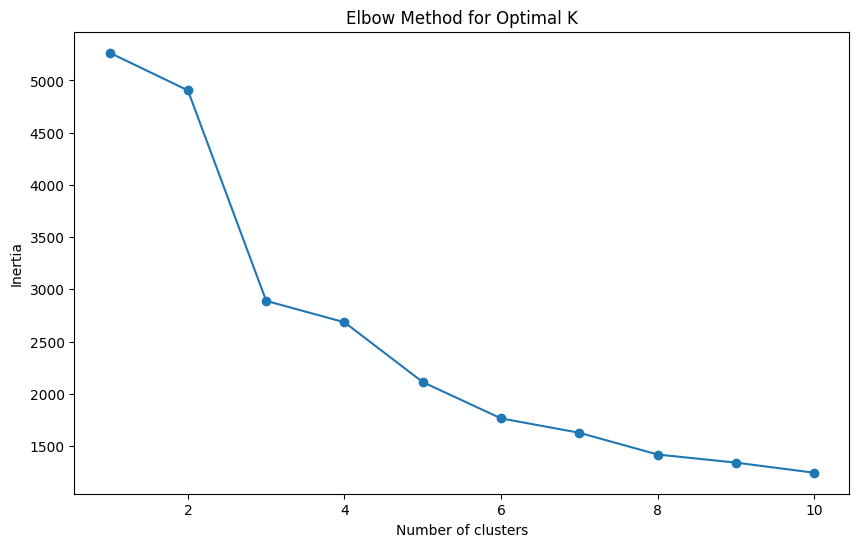

In [100]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# '공연코드' 제거 
features = Demo.drop(columns=['공연코드'])  # Drop non-numeric or identifier columns

# 수치형 자료에 대해서 정규화 실시
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 1~10개의 clustering의 개수 범위 설정 
k_range = range(1, 11)
inertia_values = []

# k숫자별로 KMeans를 적용하고 inertia 계산 
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

# Plot the inertia values to visualize the Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# gpt가 3개 하는 것이 가장 적당하다고 함 

In [101]:
# k-mean clustering을 진행한 후 해당 cluster를 cluster 예측 데이터셋에 merge

kmeans = KMeans(n_clusters=3, random_state=38)
Demo['Cluster'] = kmeans.fit_predict(scaled_features)

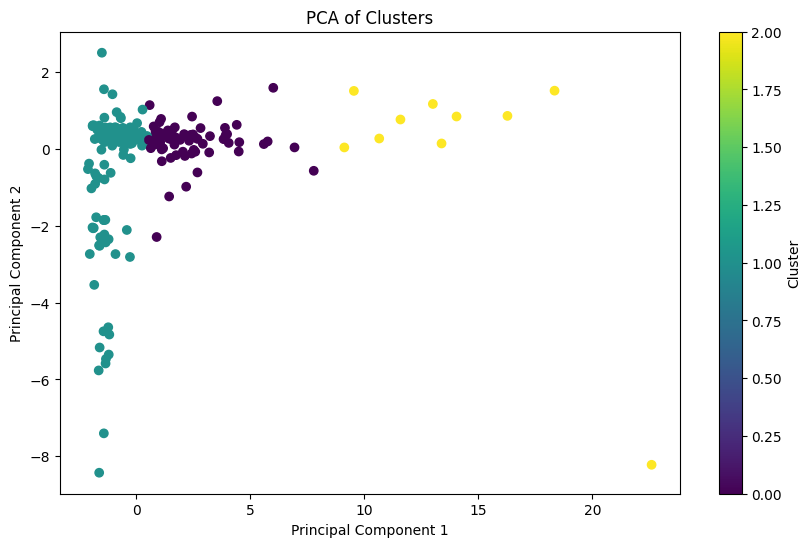

In [103]:
# clustering 시각화 
from sklearn.decomposition import PCA

# Step 1: 차원을 두개로 줄이기 
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)  # scaled_features should be used as input

# 차원 component 데이터 프레임 생성
pca_df = pd.DataFrame(data=principal_components, columns=['Principal Component 1', 'Principal Component 2'])

# Step 2: PCA 데이터프레임에 Cluster 생성 
pca_df['Cluster'] = Demo['Cluster']

# Step 3: cluster들을 시각화해서 보여주기 
plt.figure(figsize=(10, 6))
plt.scatter(pca_df['Principal Component 1'], pca_df['Principal Component 2'], c=pca_df['Cluster'], cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Clusters')
plt.colorbar(label='Cluster')
plt.show()

# 시간에 따른 판매 개수에 대해서 정규화를 통해 시각화 진행 (cluster에 대한 분포 확인)

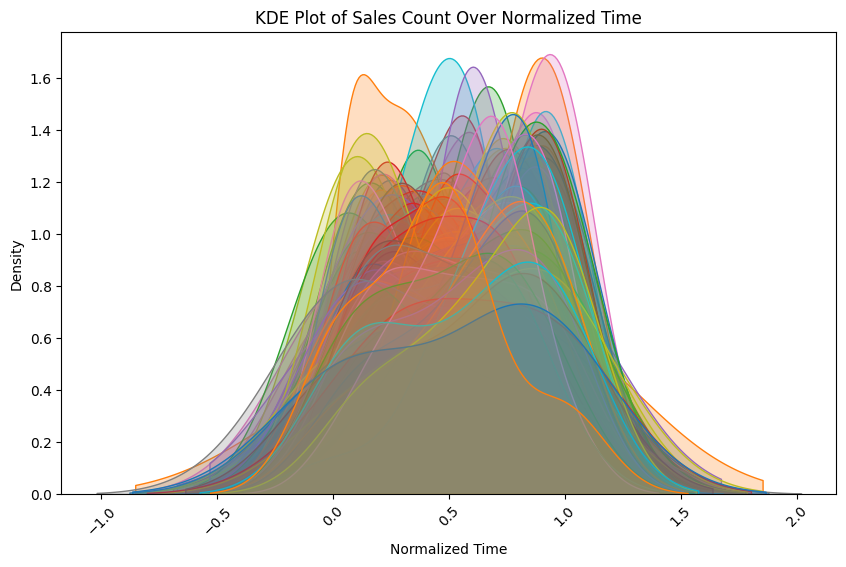

In [132]:
# cluster_1

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 시각화 사이즈 설정 
plt.figure(figsize=(10, 6))

scaler = MinMaxScaler()

for mask in Demo[Demo['Cluster'] == 1]['공연코드'].unique(): 
    df_grouped = df[df['공연코드'] == mask].loc[:, ['공연코드', '공연일시']].groupby('공연일시').count().reset_index()

    # 날짜 데이터를 정규화 (0 ~ 1 사이 값으로 변환)
    df_grouped['공연일시_norm'] = scaler.fit_transform(df_grouped[['공연일시']])
    
    # 정규화된 시간에 따른 KDE plot 생성
    sns.kdeplot(data=df_grouped, x='공연일시_norm', weights='공연코드', fill=True)
    
# 라벨 & 타이틀 
plt.xlabel('Normalized Time')
plt.ylabel('Density')
plt.title('KDE Plot of Sales Count Over Normalized Time')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# plot 보여주기
plt.show()

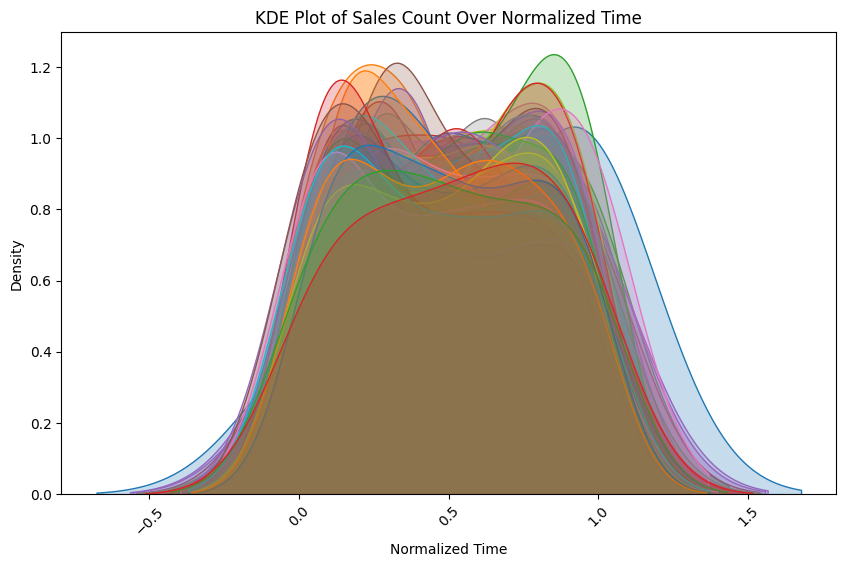

In [255]:
# cluster_0

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 시각화 사이즈 설정 
plt.figure(figsize=(10, 6))

scaler = MinMaxScaler()

for mask in Demo[Demo['Cluster'] == 0]['공연코드'].unique(): 
    df_grouped = df[df['공연코드'] == mask].loc[:, ['공연코드', '공연일시']].groupby('공연일시').count().reset_index()

    # 날짜 데이터를 정규화 (0 ~ 1 사이 값으로 변환)
    df_grouped['공연일시_norm'] = scaler.fit_transform(df_grouped[['공연일시']])
    
    # 정규화된 시간에 따른 KDE plot 생성
    sns.kdeplot(data=df_grouped, x='공연일시_norm', weights='공연코드', fill=True)
    
# 라벨 & 타이틀 
plt.xlabel('Normalized Time')
plt.ylabel('Density')
plt.title('KDE Plot of Sales Count Over Normalized Time')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# plot 보여주기
plt.show()

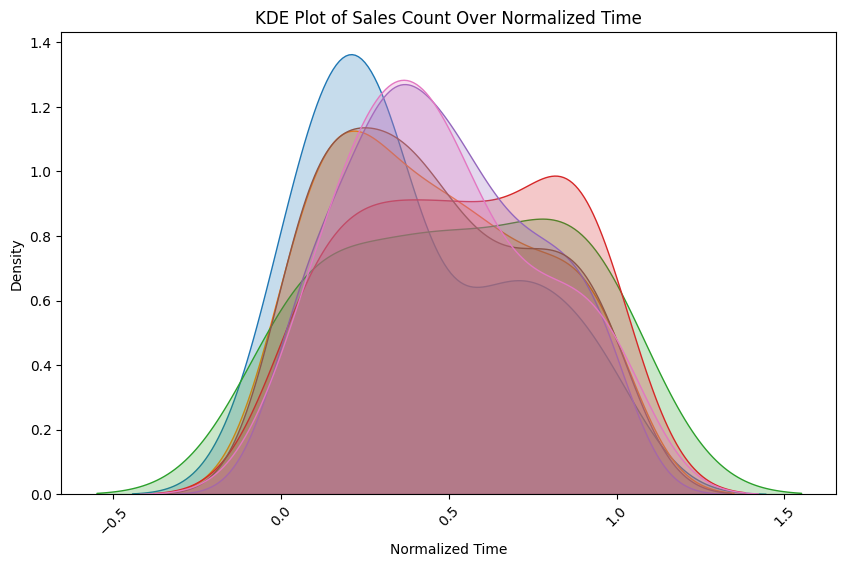

In [276]:
# cluster_2

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 시각화 사이즈 설정 
plt.figure(figsize=(10, 6))

scaler = MinMaxScaler()

for mask in Demo[Demo['Cluster'] == 2]['공연코드'].unique(): 
    df_grouped = df[df['공연코드'] == mask].loc[:, ['공연코드', '공연일시']].groupby('공연일시').count().reset_index()

    # 날짜 데이터를 정규화 (0 ~ 1 사이 값으로 변환)
    df_grouped['공연일시_norm'] = scaler.fit_transform(df_grouped[['공연일시']])
    
    # 정규화된 시간에 따른 KDE plot 생성
    sns.kdeplot(data=df_grouped, x='공연일시_norm', weights='공연코드', fill=True)
    
# 라벨 & 타이틀 
plt.xlabel('Normalized Time')
plt.ylabel('Density')
plt.title('KDE Plot of Sales Count Over Normalized Time')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# plot 보여주기
plt.show()